# Training with Self-Consistency

This notebooks shows how to train an approximator with a self-consistency (SC) loss. 

Standard amortized Bayesian inference (ABI) trains a posterior approximator on simulated parameter-observation pairs. After training, the posterior approximator can be evaluated on empirical data for inference to obtain samples from the posterior distribution of the parameters. When the empirical data lie outside of the training distribution, there are no guarantees for the posterior approximator.

The self-consistency loss addresses this by enforcing constraints implied by the Bayes' theorem. For any fixed observation $y$, the quantity
$$\log p(\theta) + \log p(y \mid \theta) - \log q(\theta \mid y)$$
equals the log marginal likelihood $\log p(y)$, which does not depend on $\theta$. This means that if the posterior approximator $q(\theta \mid y)$ is correct, the above expression must be constant across different parameter values $\theta$. The SC loss minimixes the variance of this quantity across posterior samples, pushing the approximator toward a posterior distribution that is consistent with the prior and likelihood.

The SC loss requires only a dataset of observables without parameter labels, being therefore an unsupervised loss. We use the semi-supervised approximator to combine the SC loss with the standard simulation-based losses that rely on simulated observation-parameter pairs. 

For more details about SC, please see [Schmitt et al. (2024)](https://proceedings.mlr.press/v235/schmitt24a.html) and [Mishra et al. (2025)](https://arxiv.org/abs/2501.13483).

In [1]:
import os
# we require tensorflow as backend due to using tensorflow_probability
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import numpy as np
import matplotlib.pyplot as plt
import bayesflow as bf
import tensorflow_probability as tfp

tfd = tfp.distributions

import bayesflow.experimental.self_consistency as sc


INFO:bayesflow:Using backend 'tensorflow'


## Model

We use a Normal model with a Normal-Gamma prior (mean-precision parameterization):

$$\tau \sim \text{Gamma}(2, 1), \quad \mu \mid \tau \sim \mathcal{N}(0,\, \tau^{-1}), \quad y_i \mid \mu, \tau \sim \mathcal{N}(\mu,\, \tau^{-1})$$

The Normal-Gamma prior is conjugate to the normal likelihood, so the true posterior is available analytically (which we will use for validation).

In [2]:
def sim_fn():
    tau = np.random.gamma(size=1, shape=2, scale=1)
    mu = np.random.normal(size=1, scale=1.0 / np.sqrt(tau))
    y = np.random.normal(size=10, loc=mu, scale=1.0 / np.sqrt(tau))
    return dict(mu=mu, tau=tau, y=y)

simulator = bf.make_simulator(sim_fn)

Precition $\tau$ is positive only, so we will add it's log-transform to the adapter. 

In [3]:
adapter = bf.Adapter().log("tau")

## Datasets

Here we have two datasets:
- **labeled**: simulated data with known parameters `(mu, tau)` and the observations `y` — used for standard posterior training.
- **unlabeled**: empirical observations `y` only, drawn from any generating model. Since no true parameter values are required, these may be real-world data as well. Here, the unlabeled data are simulated and set to have high variance (low precision). Therefore, we know they are out-of-distribution with respect to the assumed model.

In principle, the `SemiSupervisedApproximator` can be trained on any number of datasets. This allows, for example, separate supervised training of a posterior and likelihood network (when the likelihood is not analytic).

In [4]:
dataset_labeled = bf.OnlineDataset(
    simulator=simulator,
    adapter=adapter,
    batch_size=64, num_batches=50)

The unlabeled dataset does not contain the parameters, and adapter only contains transformations of the parameters. Therefore, the adapter for the unlabeled dataset can remain empty.

In [5]:
dataset_unlabeled = bf.OfflineDataset(
    data=dict(y=np.random.normal(loc=0.0, scale=10, size=(32, 10))),
    adapter=bf.Adapter(),
    batch_size=8
)

We wrap all datasets that we use for training into one dataset class. Each batch will be a dictionary containing batches from individual data sets.

In [6]:
dataset = sc.MultiDataset(labeled=dataset_labeled, unlabeled=dataset_unlabeled)

print(dataset[0].keys())
print(dataset[0]["labeled"].keys())
print(dataset[0]["unlabeled"].keys())

dict_keys(['labeled', 'unlabeled'])
dict_keys(['mu', 'tau', 'y'])
dict_keys(['y'])


## Prior and likelihood

The SC loss needs access to the prior and likelihood log-densities.

Here we define prior and likelihood analytically. Alternatively, they can be also approximated.

Note that these functions receive parameters in the **original** (un-transformed) space. Therefore, you do not need to transform $\tau$ manually to the log space. However, the evaluation of log-densities is currently not auto-batched, so you have to take care of batching yourself, and you have to define the log_prob with keras tensor operations (so that they can be evaluated during training). Here, we use tensorflow probability distributions, which help us do that.

In [7]:
def prior_log_prob(mu, tau, **kwargs):
    tau_log_prob = tfd.Gamma(concentration=2.0, rate=1.0).log_prob(tau)
    mu_log_prob = tfd.Normal(loc=0.0, scale=1.0 / keras.ops.sqrt(tau)).log_prob(mu)
    return mu_log_prob + tau_log_prob

In [8]:
def likelihood_log_prob(y, mu, tau, **kwargs):
    y_log_prob = tfd.Normal(loc=mu, scale=1.0 / keras.ops.sqrt(tau)).log_prob(y)
    return keras.ops.sum(y_log_prob, axis=1)

## Posterior approximator

A `ContinuousApproximator` with a `CouplingFlow` inference network and a `DeepSet` summary network. Notice that we specify an additional adapter for the approximator itself. This local adapter will be run after the global adapter that transforms tau. The global adapter takes care of operations that are needed for all approximators, whereas local adapters like here reshape data as needed for the specific approximator. Here, the adapter specifies that `mu` and `tau` are the inference variables and `y` is the summary variables - hence, specifying a posterior network.

In [9]:
posterior_adapter=(
    bf.Adapter()
    .as_set("y")
    .concatenate(["mu", "tau"], into="inference_variables")
    .rename("y", "summary_variables")
)

In [10]:
posterior = bf.ContinuousApproximator(
    inference_network=bf.networks.CouplingFlow(),
    summary_network=bf.networks.DeepSet(),
    adapter = posterior_adapter,
    #standardize=None
)

The main approximator wraps all approximator in one object. Here we have analytic prior and likelihood, and approximate posterior.

In [11]:
approximator = sc.SemiSupervisedApproximator(
    approximators={
        "prior": prior_log_prob,
        "likelihood": likelihood_log_prob,
        "posterior": posterior,
    },
    adapter=adapter,
)

Before training, we will also generate some synthetic data for evaluation. Here the data is generated with a high variance (low precision). The data is therefore out-of-distribution wrt the simulator, but not out-of-distribution wrt the unlabeled data.

In [12]:
eval_data = dict(y=np.random.normal(loc=0.0, scale=10, size=(1, 10)))
samples = dict()

## Phase 1: Supervised training only

First we can train the posterior on labeled (simulated) data only. We do this by specifying which approximator (here, `posterior`) train on which data set (here: `labeled`), using the approximator-specific metrics.

In [13]:
schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=100 * dataset.num_batches
)
optimizer = keras.optimizers.Adam(schedule, clipvalue=1.0)

approximator.compile(
    optimizer,
    approximator_metrics={"labeled": ["posterior"]}
)

history = approximator.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - labeled/posterior/loss: 1.3908 - loss: 1.3908
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - labeled/posterior/loss: 1.0385 - loss: 1.0385
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - labeled/posterior/loss: 1.0066 - loss: 1.0066
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/posterior/loss: 0.9769 - loss: 0.9769
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - labeled/posterior/loss: 0.9669 - loss: 0.9669
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/posterior/loss: 0.9291 - loss: 0.9291
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/posterior/loss: 0.9414 - loss: 0.9414
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/posterior/loss: 0.9094 - loss: 0.9094
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - labeled/posterior/loss: 0.9398 - loss: 0.9398
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - labeled/posterior/loss: 0.8779 - loss: 0.8779


In [14]:
samples["No SC"] = approximator.sample(approximator="posterior", num_samples=1000, conditions=eval_data)

Sampling: 100%|██████████| 1/1 [00:00<00:00, 13.71batch/s]


## Phase 2: Self-consistency training

Add the SC loss on unlabeled data and continue training. The SC loss enforces Bayes' theorem:

$$\log p(y) = \log p(\mu, \tau) + \log p(y \mid \mu, \tau) - \log q(\mu, \tau \mid y)$$

should have zero variance across parameter samples, which drives the posterior toward consistency with the prior and likelihood.

We add the SC loss by specifying that composite metrics (metrics that require a combination of multiple approximators) on the `unlabeled` data set.

In [15]:
approximator.compile(
    optimizer,
    approximator_metrics={"labeled": ["posterior"]},
    composite_metrics={
        "unlabeled": sc.SelfConsistencyLoss(num_samples=16)
    }
)

history = approximator.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - labeled/posterior/loss: 1.4807 - loss: 15.5507 - unlabeled/self-consistency/loss: 14.0700
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - labeled/posterior/loss: 1.1087 - loss: 1.6531 - unlabeled/self-consistency/loss: 0.5443
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - labeled/posterior/loss: 0.9235 - loss: 1.1906 - unlabeled/self-consistency/loss: 0.2671
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - labeled/posterior/loss: 0.8993 - loss: 1.2045 - unlabeled/self-consistency/loss: 0.3052
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - labeled/posterior/loss: 0.9074 - loss: 1.1440 - unlabeled/self-consistency/loss: 0.2366
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - labeled/posterior/loss: 0.8856 - loss: 1.1130 - unlabeled/self-consistency/loss: 0.2275
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - labeled/posterior/loss: 0.9021 - loss: 1.1572 - unlabeled/self-consistency/loss: 0.2552
Epoch 8/10

In [16]:
samples["SC"] = approximator.sample(approximator="posterior", num_samples=1000, conditions=eval_data)

Sampling: 100%|██████████| 1/1 [00:00<00:00, 14.50batch/s]


## Evaluation

Now we compare the results from simulation-based training and self-consistency training.

The Normal-Gamma posterior is available in closed form, so we will compare posterior samples from both training methods to samples from this reference

In [17]:
def sample_posterior(y, n_samples, mu0=0.0, kappa=1.0, shape=2.0, scale=1.0):
    y = y.flatten()
    n = len(y)
    ybar = np.mean(y)
    S = np.sum((y - ybar) ** 2)

    kappa_n = kappa + n
    mu_n = (kappa * mu0 + n * ybar) / kappa_n
    shape_n = shape + n / 2
    rate_n = 1 / scale + 0.5 * S + (kappa * n / (2 * kappa_n)) * (ybar - mu0) ** 2

    tau = np.random.gamma(shape=shape_n, scale=1.0 / rate_n, size=n_samples)
    mu = np.random.normal(loc=mu_n, scale=1.0 / np.sqrt(kappa_n * tau), size=n_samples)

    return dict(mu=mu, tau=tau)


samples["Reference"] = sample_posterior(eval_data["y"], n_samples=1000)

Samples from the approximator trained with the SC loss are much more similar to the reference than pure simulation-based training.

Text(0, 0.5, '$\\tau$')

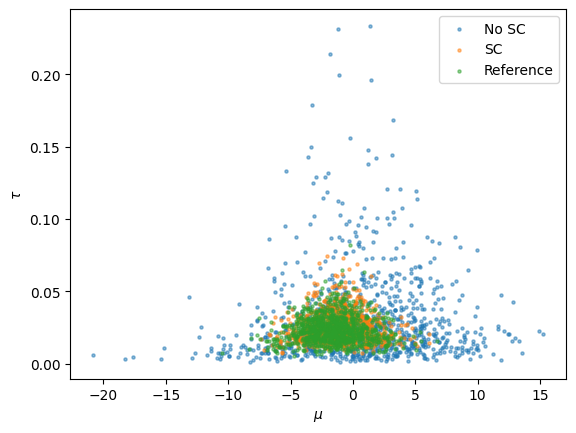

In [18]:
for k, s in samples.items():
    plt.scatter(s["mu"].flatten(), s["tau"].flatten(), label=k, alpha=0.5, s=5.0)
f=plt.legend()
plt.xlabel("$\\mu$")
plt.ylabel("$\\tau$")

## Approximate posterior and likelihood

Prior and likelihood do not need to be analytic, and can be also approximated. The trick is to specify multiple approximators that take different arguments are inference variables/summary variables/inference conditions.

Here is how we would approximate both posterior and likelihood (NPLE) and train them with self consistency.

First, we define the posterior approximator as previously.

In [19]:
posterior_adapter=(
    bf.Adapter()
    .as_set("y")
    .concatenate(["mu", "tau"], into="inference_variables")
    .rename("y", "summary_variables")
)

In [20]:
posterior_approx = bf.ContinuousApproximator(
    inference_network = bf.networks.CouplingFlow(),
    summary_network = bf.networks.DeepSet(),
    adapter = posterior_adapter,
)

Then, define a likelihood approximator. Thi approximator predicts the distribution of data `y` given parameters `mu` and `tau`. Therefore, the likelihood adapter uses `mu` and `tau` as inference conditions, and `y` as inference variables.

In [21]:
likelihood_adapter = (
    bf.Adapter()
    .concatenate(["mu", "tau"], into="inference_conditions")
    .rename("y", "inference_variables")
)

In [22]:
likelihood_approx = bf.ContinuousApproximator(
    inference_network = bf.networks.CouplingFlow(),
    summary_network = None,
    adapter = likelihood_adapter,
)

In [23]:
approximator_nple = sc.SemiSupervisedApproximator(
    approximators = {
        "prior": prior_log_prob,
        "likelihood": likelihood_approx,
        "posterior": posterior_approx
    },
    adapter=adapter
)

Typically, it's a good idea to pretrain the networks with pure simulation-based training. Now we need to specify that both posterior and likelihood approximators need to be trained with their own metrics, evaluated on the labeled data set.

In [24]:
approximator_nple.compile(
  keras.optimizers.Adam(schedule, clipvalue=1.0),
  approximator_metrics = {"labeled": ["posterior", "likelihood"]}
)

history = approximator_nple.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - labeled/likelihood/loss: 10.6259 - labeled/posterior/loss: 1.4231 - loss: 12.0490
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - labeled/likelihood/loss: 9.0982 - labeled/posterior/loss: 1.0898 - loss: 10.1880
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/likelihood/loss: 8.9523 - labeled/posterior/loss: 1.0180 - loss: 9.9702
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/likelihood/loss: 8.9273 - labeled/posterior/loss: 1.0034 - loss: 9.9307
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - labeled/likelihood/loss: 8.9869 - labeled/posterior/loss: 0.9976 - loss: 9.9846
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/likelihood/loss: 8.8697 - labeled/posterior/loss: 0.9596 - loss: 9.8293
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - labeled/likelihood/loss: 8.9139 - labeled/posterior/loss: 0.9930 - loss: 9.9069
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - labeled/like

After that, we can do SC training. Note that by default, only the posterior network is trained with self-consistency. You can change that using the argument `gradient` in `sc.SelfConsistencyLoss`.

In [25]:
approximator_nple.compile(
  keras.optimizers.Adam(schedule, clipvalue=1.0),
  approximator_metrics = {"labeled": ["posterior", "likelihood"]},
  composite_metrics = {
      "unlabeled": sc.SelfConsistencyLoss(num_samples=16)
  }
)

history = approximator_nple.fit(dataset=dataset, epochs=10)

INFO:bayesflow:Fitting on dataset instance of MultiDataset.


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - labeled/likelihood/loss: 8.6656 - labeled/posterior/loss: 1.0707 - loss: 53.3068 - unlabeled/self-consistency/loss: 43.5706
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - labeled/likelihood/loss: 8.8556 - labeled/posterior/loss: 0.9710 - loss: 11.8587 - unlabeled/self-consistency/loss: 2.0321
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - labeled/likelihood/loss: 8.6953 - labeled/posterior/loss: 0.8866 - loss: 10.9018 - unlabeled/self-consistency/loss: 1.3199
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - labeled/likelihood/loss: 8.8455 - labeled/posterior/loss: 0.9332 - loss: 10.9451 - unlabeled/self-consistency/loss: 1.1663
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - labeled/likelihood/loss: 8.9724 - labeled/posterior/loss: 0.9253 - loss: 10.9559 - unlabeled/self-consistency/loss: 1.0582
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - labeled/likelihood/loss: 8.8486 - labeled/posterior/loss: 0.8782 

In [28]:
samples["SC, approximate likelihood"] = approximator_nple.sample(approximator="posterior", num_samples=1000, conditions=eval_data)

Sampling: 100%|██████████| 1/1 [00:00<00:00, 13.17batch/s]


Text(0, 0.5, '$\\tau$')

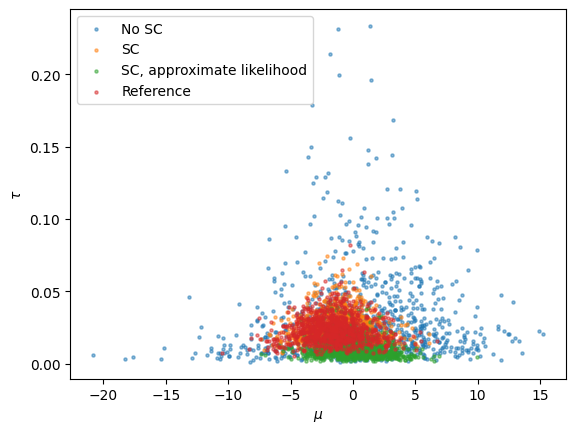

In [29]:
items = ["No SC", "SC", "SC, approximate likelihood", "Reference"]

for k in items:
    s = samples[k]
    plt.scatter(s["mu"].flatten(), s["tau"].flatten(), label=k, alpha=0.5, s=5.0)
f=plt.legend()
plt.xlabel("$\\mu$")
plt.ylabel("$\\tau$")